# 2020 年以来固定合约对换月价差：延续、反转与盘口方向

本 Notebook 研究中金所、上期所和上海国际能源交易中心的高流动性品种。每次主力切换先冻结展出旧合约和展入新合约；之后只读取 `backtest_1s` 中这两张合约的同秒买一卖一，不使用 HFQ、连续合约或日线收盘价。

研究范围为 2020-01-01 至主力切换数据的最后可用日 2026-08-26。每个品种单独一页小 multiples，一格一场换月，格标题写换月日和旧→新合约。

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

RESEARCH_ROOT = Path('/home/fanghaizhou/mkt_signal')
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

from research.roll_spread.historical_reversal import CN_PRODUCT_NAMES

OUTPUT_DIR = Path('/mnt/nvme-raid0-28t/fanghaizhou/roll_spread_study/20260909_cn_historical_reversal')
summary = pd.read_csv(OUTPUT_DIR / 'product_reversal_summary.csv')
exchange_summary = pd.read_csv(OUTPUT_DIR / 'exchange_reversal_summary.csv')
audit = pd.read_csv(OUTPUT_DIR / 'daily_mark_audit.csv')
manifest = pd.read_csv(OUTPUT_DIR / 'product_path_manifest.csv')
print('计划日数:', len(audit))
print(audit['status'].value_counts().to_string())

计划日数: 12430
status
ok                           12379
missing_parquet                 46
insufficient_pair_seconds        5


## 预先固定的统计量

交易日的市场状态用所有有效同秒配对的对数 mid spread 均值（bp）表示：

$$m_d = 10{,}000\times \operatorname{mean}_{s\in d}\left[\ln\left(\frac{mid_{old,s}}{mid_{new,s}}\right)\right].$$

早段变化为 $E=m_{-6}-m_{-10}$，晚段变化为 $L=m_{-1}-m_{-6}$。若 $E$ 与 $L$ 异号，记为反转；同号，记为延续。

主要统计指标是每品种的反转率 $R=\Pr(EL<0)$，用精确二项检验比较 $R=50\%$，并在 27 个品种上做 Benjamini-Hochberg FDR 校正。为了避免只看正负号，也报告 $\operatorname{mean}[\operatorname{sign}(E)L]$ 的 100,000 次可复现符号置换检验。负值表示平均幅度回转，正值表示平均幅度延续。

In [2]:
show_columns = [
    'exchange', 'product', 'product_name', 'directional_events', 'reversal_rate',
    'reversal_pvalue', 'reversal_qvalue', 'mean_aligned_late_mid_change_bps',
    'aligned_mean_signflip_pvalue', 'aligned_mean_signflip_qvalue', 'trend_conclusion',
]
display(summary[show_columns].style.format({
    'reversal_rate': '{:.1%}', 'reversal_pvalue': '{:.3f}', 'reversal_qvalue': '{:.3f}',
    'mean_aligned_late_mid_change_bps': '{:+.1f}',
    'aligned_mean_signflip_pvalue': '{:.3f}', 'aligned_mean_signflip_qvalue': '{:.3f}',
}))
display(Markdown('### 按交易所汇总（只作描述，不替代逐品种推断）'))
display(exchange_summary.style.format({
    'reversal_rate': '{:.1%}', 'reversal_pvalue': '{:.3f}',
    'mean_aligned_late_mid_change_bps': '{:+.1f}', 'aligned_mean_signflip_pvalue': '{:.3f}',
}))

,exchange,product,product_name,directional_events,reversal_rate,reversal_pvalue,reversal_qvalue,mean_aligned_late_mid_change_bps,aligned_mean_signflip_pvalue,aligned_mean_signflip_qvalue,trend_conclusion
0,ccfx,IC,中证500股指期货,29,55.2%,0.711,1.000,-7.9,0.076,0.511,未显著
1,ccfx,IF,沪深300股指期货,33,51.5%,1.000,1.000,-0.6,0.882,0.933,未显著
2,ccfx,IH,上证50股指期货,35,40.0%,0.311,1.000,+10.0,0.048,0.511,未显著
3,ccfx,IM,中证1000股指期货,18,50.0%,1.000,1.000,-0.6,0.893,0.933,未显著
4,ccfx,T,10年期国债期货,27,40.7%,0.442,1.000,+2.2,0.297,0.802,未显著
5,ccfx,TF,5年期国债期货,27,37.0%,0.248,1.000,+0.5,0.793,0.933,未显著
6,ccfx,TL,30年期国债期货,14,50.0%,1.000,1.000,+1.7,0.416,0.802,未显著
7,ccfx,TS,2年期国债期货,27,48.1%,1.000,1.000,+0.2,0.853,0.933,未显著
8,xsge,AG,白银期货,25,52.0%,1.000,1.000,+0.9,0.652,0.933,未显著
9,xsge,AL,铝期货,79,57.0%,0.260,1.000,-1.5,0.525,0.861,未显著


### 按交易所汇总（只作描述，不替代逐品种推断）

,exchange,events_complete,directional_events,reversal_events,continuation_events,reversal_rate,reversal_pvalue,mean_aligned_late_mid_change_bps,median_aligned_late_mid_change_bps,aligned_mean_signflip_pvalue,follow_events,follow_mean_gross_bbo_pnl_bps,follow_median_gross_bbo_pnl_bps,follow_win_rate,follow_win_pvalue,contrarian_events,contrarian_mean_gross_bbo_pnl_bps,contrarian_median_gross_bbo_pnl_bps,contrarian_win_rate,contrarian_win_pvalue
0,ccfx,210,210,97,113,46.2%,0.301,+0.9,1.425785,0.506,210,-2.189173,-1.272852,0.452381,0.189690,210,-4.031969,-3.843998,0.409524,0.010501
1,xsge,737,737,395,342,53.6%,0.055,-3.8,-1.431161,0.047,737,-12.648760,-7.410045,0.318860,0.000000,737,-2.837420,-4.355360,0.382632,0.000000
2,xsie,284,284,145,139,51.1%,0.767,+3.2,-1.349236,0.379,284,-17.920186,-17.852264,0.316901,0.000000,284,-27.611519,-20.831781,0.271127,0.000000


## 全品种比较

虚线是 50% 的随机方向基准；柱顶 `n` 是具有非零早、晚段变化的完整事件数。此图不以颜色制造结论：若某个品种通过 FDR 10%，柱会被强调；本次全样本没有这样的品种。

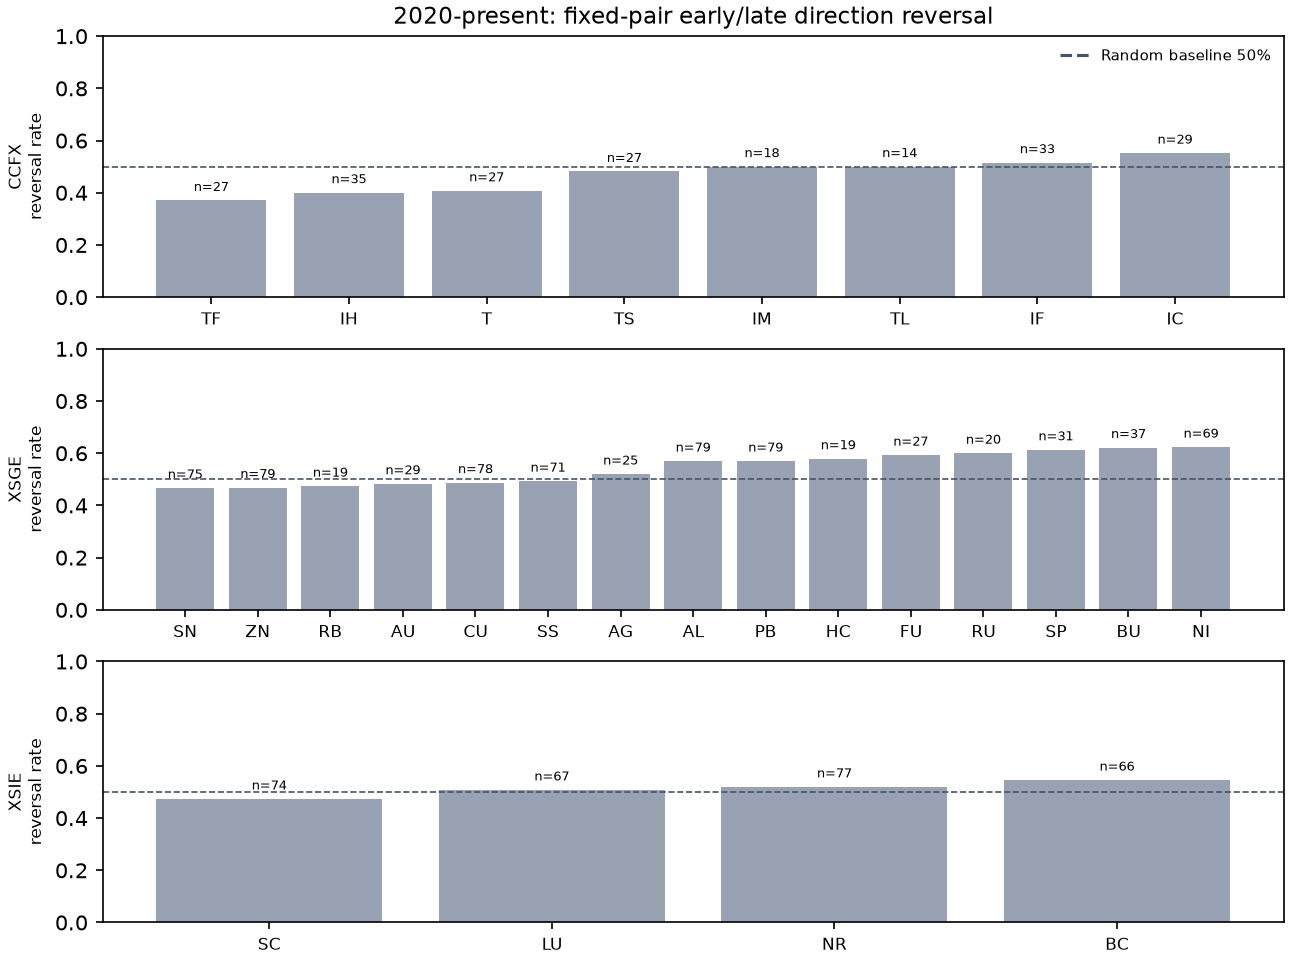

In [3]:
display(Image(filename=str(OUTPUT_DIR / 'product_reversal_rate.png')))

## 每品种的逐次换月路径

一格是一场换月，不是全部事件叠在同一坐标上。路径仍按 $E$ 的正负对齐，所以 `t=-10` 到 `t=-6` 总是向上；`t=-6` 之后向下是回转，向上是延续。蓝线是延续，橙线是反转。同一品种共用纵轴，幅度小的格子接近水平是真实尺度。

In [ ]:
for exchange in ('ccfx', 'xsge', 'xsie'):
    display(Markdown(f'### {exchange.upper()}'))
    for row in manifest[manifest['exchange'].eq(exchange)].itertuples(index=False):
        display(Markdown(f'**{row.product} {CN_PRODUCT_NAMES[row.product]}，{row.events} 次换月**'))
        display(Image(filename=str(OUTPUT_DIR / 'product_paths' / row.image_file), width=980))

## 多空方向的收盘 BBO 筛选

这不是成交回测，而是因果的双腿盘口标记：以 `t=-10 -> -6` 的 mid 变化决定顺势方向，`t=-6` 的最后一个同步 BBO 建仓，`t=-1` 的最后一个同步 BBO 平仓。

- 早段为正：多旧空新；收益为 `t=-1` 的卖旧买新对数 BBO 减去 `t=-6` 的买旧卖新对数 BBO。
- 早段为负：空旧多新；收益为 `t=-6` 的卖旧买新对数 BBO 减去 `t=-1` 的买旧卖新对数 BBO。
- 反向栏持有相反方向。所有结果均未计手续费、滑点、盘口量和两腿成交不同步风险。

In [5]:
bbo_columns = [
    'exchange', 'product', 'product_name', 'follow_events', 'follow_median_gross_bbo_pnl_bps',
    'follow_win_rate', 'follow_win_qvalue', 'contrarian_events',
    'contrarian_median_gross_bbo_pnl_bps', 'contrarian_win_rate', 'contrarian_win_qvalue',
]
display(summary[bbo_columns].style.format({
    'follow_median_gross_bbo_pnl_bps': '{:+.1f}', 'follow_win_rate': '{:.1%}', 'follow_win_qvalue': '{:.3g}',
    'contrarian_median_gross_bbo_pnl_bps': '{:+.1f}', 'contrarian_win_rate': '{:.1%}', 'contrarian_win_qvalue': '{:.3g}',
}))

,exchange,product,product_name,follow_events,follow_median_gross_bbo_pnl_bps,follow_win_rate,follow_win_qvalue,contrarian_events,contrarian_median_gross_bbo_pnl_bps,contrarian_win_rate,contrarian_win_qvalue
0,ccfx,IC,中证500股指期货,29,-10.2,34.5%,0.274,29,+2.0,51.7%,1
1,ccfx,IF,沪深300股指期货,33,-0.5,45.5%,0.894,33,-4.4,42.4%,0.692
2,ccfx,IH,上证50股指期货,35,-3.1,48.6%,1,35,-11.4,34.3%,0.236
3,ccfx,IM,中证1000股指期货,18,-0.3,50.0%,1,18,-4.5,27.8%,0.236
4,ccfx,T,10年期国债期货,27,-3.0,48.1%,1,27,+1.0,51.9%,1
5,ccfx,TF,5年期国债期货,27,+2.9,59.3%,0.597,27,-4.8,40.7%,0.692
6,ccfx,TL,30年期国债期货,14,-3.4,35.7%,0.597,14,-0.9,42.9%,0.967
7,ccfx,TS,2年期国债期货,27,-0.8,37.0%,0.418,27,-2.0,33.3%,0.275
8,xsge,AG,白银期货,25,-2.9,32.0%,0.242,25,-2.2,36.0%,0.443
9,xsge,AL,铝期货,79,-8.1,25.3%,0.000175,79,-4.4,39.2%,0.236


## 可复核产物

`daily_mid_and_eod_bbo.csv` 保存每个固定合约对、每个交易日的日内 mid 均值和最后同步 BBO；`daily_mark_audit.csv` 保存缺失日和无足够同秒报价日；`event_reversal_statistics.csv` 保存事件级早段、晚段、方向和两种 BBO 毛收益；`product_reversal_summary.csv` 是所有显著性结论的来源；`product_path_manifest.csv` 记录每张图和逐次换月标签。